In [1]:
# load any libraries we will need
import pandas as pd
import seaborn as sns

# initial import of data
raw_data = pd.read_csv('DOHMH_New_York_City_Restaurant_Inspection_Results_20260713.csv')
raw_data

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50134465,CHICKEN STOP,Brooklyn,1274,FULTON STREET,11216.0,9176097474,Chicken,09/28/2024,No violations were recorded at the time of thi...,...,Inter-Agency Task Force / Initial Inspection,40.680395,-73.949899,303.0,36.0,24700.0,3053721.0,3.018600e+09,BK61,POINT (-73.949899433468 40.680394569627)
1,50173653,LAVISH BAR & RESTAURANT,Brooklyn,3412,FULTON STREET,11208.0,9294079809,NaN,01/01/1900,NaN,...,NaN,40.684320,-73.869787,305.0,37.0,118400.0,3092914.0,3.041490e+09,BK83,POINT (-73.869787036268 40.684319718483)
2,50141618,DIM SUM KING & BAKERY,Brooklyn,2480,86 STREET,11214.0,7188726086,Chinese,03/13/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.598168,-73.987624,311.0,43.0,30000.0,3185638.0,3.068660e+09,BK29,POINT (-73.987623577637 40.598168449423)
3,50117966,HOUSE OF THAI,Queens,25-01,40 AVENUE,11101.0,9295220247,Thai,12/04/2023,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.753427,-73.937818,401.0,26.0,3300.0,4004782.0,4.003960e+09,QN68,POINT (-73.937817894944 40.753426947698)
4,50109566,NUNU BAR,Brooklyn,38,AVENUE O,11204.0,7188807138,Mediterranean,02/14/2025,No violations were recorded at the time of thi...,...,Smoke-Free Air Act / Initial Inspection,40.610231,-73.983703,311.0,44.0,43000.0,3174147.0,3.065970e+09,BK29,POINT (-73.983702801906 40.610231294411)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296054,50118687,PADOCA BAKERY,Manhattan,1663,1 AVENUE,10028.0,9174883720,Bakery Products/Desserts,04/07/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.777238,-73.949119,108.0,5.0,14602.0,1050033.0,1.015490e+09,MN32,POINT (-73.949118601091 40.777237798059)
296055,50156031,WENDY'S,Queens,69-02,NORTHERN BOULEVARD,11377.0,2018184669,Hamburgers,09/13/2024,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,40.754284,-73.897338,403.0,25.0,29100.0,4028472.0,4.012420e+09,QN28,POINT (-73.897337547753 40.754284429156)
296056,50001986,HOOTERS,Queens,61-09,190 STREET,11365.0,7184542800,American,11/29/2022,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.740970,-73.784641,408.0,23.0,134700.0,4444050.0,4.071170e+09,QN41,POINT (-73.784640665441 40.740969835709)
296057,50116136,SMART 3 CAFE,Queens,168-45,HILLSIDE AVENUE,11432.0,9299903996,Bangladeshi,04/12/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.710467,-73.793638,408.0,24.0,45400.0,4210547.0,4.098410e+09,QN35,POINT (-73.79363815793 40.71046723066)


# investigate distribution of violation codes

In [3]:
raw_data.dtypes

CAMIS                      int64
DBA                          str
BORO                         str
BUILDING                     str
STREET                       str
ZIPCODE                  float64
PHONE                        str
CUISINE DESCRIPTION          str
INSPECTION DATE              str
ACTION                       str
VIOLATION CODE               str
VIOLATION DESCRIPTION        str
CRITICAL FLAG                str
SCORE                    float64
GRADE                        str
GRADE DATE                   str
RECORD DATE                  str
INSPECTION TYPE              str
Latitude                 float64
Longitude                float64
Community Board          float64
Council District         float64
Census Tract             float64
BIN                      float64
BBL                      float64
NTA                          str
Location                     str
dtype: object

In [4]:
raw_data['VIOLATION CODE'].unique()

<StringArray>
[    nan,   '04L',   '08A',   '05A', '20-08',   '08B',   '10B',   '06C',
   '02G',   '04A',
 ...
   '05I', '15-36',   '06H',   '15K', '15-26',   '22B',   '18B', '20-03',
   '18D',   '16K']
Length: 156, dtype: str

In [5]:
raw_data['VIOLATION CODE'].value_counts()

VIOLATION CODE
10F      41284
08A      25539
10B      18810
06C      18680
02G      18676
         ...  
22B          1
18B          1
20-03        1
18D          1
16K          1
Name: count, Length: 155, dtype: int64

# most popular violation codes are 10F and 08A

In [6]:
# let's filter to only rows with violation code 10F
# first check what the description is
raw_data[raw_data['VIOLATION CODE'] == '10F']['VIOLATION DESCRIPTION'].unique()

<StringArray>
['Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.', 'Non-food contact surface improperly constructed. Unacceptable material used. Non-food contact surface or equipment improperly maintained and/or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.']
Length: 2, dtype: str

In [7]:
# let's filter to only rows with violation code 08A
# first check what the description is
raw_data[raw_data['VIOLATION CODE'] == '08A']['VIOLATION DESCRIPTION'].unique()

<StringArray>
[                                'Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.',
 'Facility not vermin proof. Harborage or conditions conducive to attracting vermin to the premises and/or allowing vermin to exist.',
                                                      'Facility not vermin proof. Harborage or conditions conducive to vermin exist.']
Length: 3, dtype: str

*08A violations seem more pressing and relevant to us*

In [8]:
raw_data[raw_data['VIOLATION CODE'] == '08A'][['BORO']]

,BORO
3,Queens
33,Brooklyn
34,Bronx
35,Manhattan
56,Brooklyn
...,...
295993,Brooklyn
295998,Manhattan
296001,Manhattan
296016,Manhattan


In [9]:
only_08A = raw_data[raw_data['VIOLATION CODE'] == '08A']

summary_08A = only_08A[['VIOLATION CODE', 'BORO']].groupby(['BORO']).count()
summary_08A

,VIOLATION CODE
BORO,
0,26
Bronx,2588
Brooklyn,6748
Manhattan,9055
Queens,6320
Staten Island,802


<Axes: xlabel='BORO', ylabel='count'>

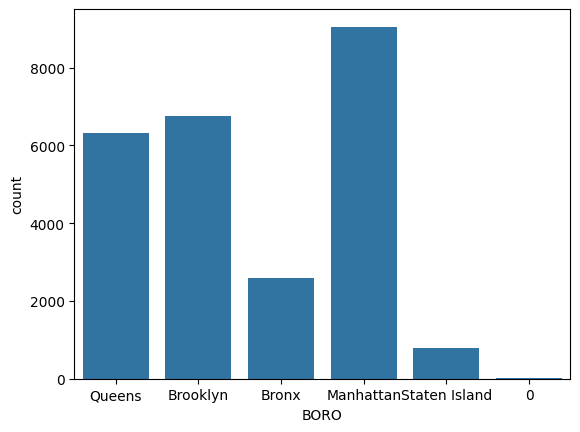

In [10]:
sns.countplot(only_08A, x='BORO')

In [11]:
aggregated_violation_code = raw_data[['BORO', 'VIOLATION CODE']]
aggregated_violation_code

,BORO,VIOLATION CODE
0,Brooklyn,NaN
1,Brooklyn,NaN
2,Brooklyn,04L
3,Queens,08A
4,Brooklyn,NaN
...,...,...
296054,Manhattan,02B
296055,Queens,10F
296056,Queens,10F
296057,Queens,03A


In [12]:
aggregated_violation_code['is_08A'] = aggregated_violation_code['VIOLATION CODE'].apply(lambda x: x == '08A')
aggregated_violation_code

,BORO,VIOLATION CODE,is_08A
0,Brooklyn,NaN,False
1,Brooklyn,NaN,False
2,Brooklyn,04L,False
3,Queens,08A,True
4,Brooklyn,NaN,False
...,...,...,...
296054,Manhattan,02B,False
296055,Queens,10F,False
296056,Queens,10F,False
296057,Queens,03A,False


<Axes: xlabel='BORO', ylabel='Count'>

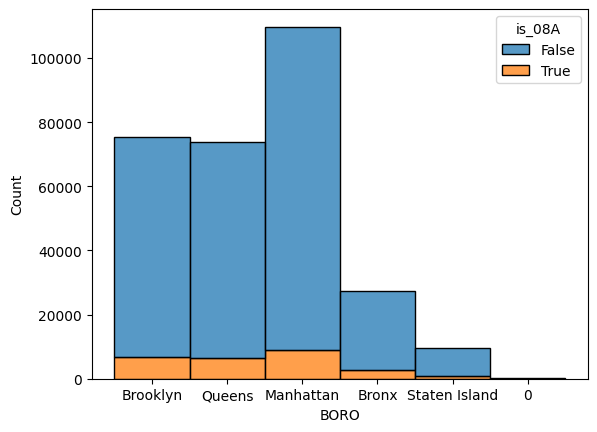

In [13]:
sns.histplot(
    aggregated_violation_code,
    x="BORO",
    hue="is_08A",
    multiple='stack'
)

# which cuisine is most prone to 08A violations

In [14]:
cuisine_x_vc = raw_data[['CUISINE DESCRIPTION', 'VIOLATION CODE']]
cuisine_x_vc

,CUISINE DESCRIPTION,VIOLATION CODE
0,Chicken,NaN
1,NaN,NaN
2,Chinese,04L
3,Thai,08A
4,Mediterranean,NaN
...,...,...
296054,Bakery Products/Desserts,02B
296055,Hamburgers,10F
296056,American,10F
296057,Bangladeshi,03A


In [15]:
# let's examine correlation between the variables first
# because CUISINE DESCRIPTION and VIOLATION CODE are strings, we need a frequency matrix of counts

contingency_table = pd.crosstab(
    cuisine_x_vc['CUISINE DESCRIPTION'],
    cuisine_x_vc['VIOLATION CODE']
);
contingency_table

VIOLATION CODE,02A,02B,02C,02D,02F,02G,02H,02I,03A,03B,...,22C,22E,22F,22G,28-01,28-03,28-04,28-05,28-06,28-07
CUISINE DESCRIPTION,,,,,,,,,,,,,,,,,,,,,
Afghan,0,4,0,0,0,5,1,0,0,0,...,0,0,0,0,0,0,0,1,4,0
African,1,129,5,0,0,75,26,1,10,0,...,0,0,0,0,2,1,1,2,13,0
American,44,1629,40,6,18,2777,384,19,107,10,...,1,0,0,0,132,39,23,40,177,2
Armenian,0,4,0,0,0,9,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Asian/Asian Fusion,5,385,2,0,10,353,53,1,39,5,...,0,0,0,0,10,5,11,12,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tex-Mex,2,143,4,0,0,142,35,2,7,1,...,1,0,0,1,10,2,0,6,23,0
Thai,9,278,7,0,1,422,51,5,20,8,...,0,0,0,0,7,6,8,2,17,0
Turkish,4,35,1,1,0,63,15,0,3,2,...,1,0,0,0,3,0,1,1,3,0


<Axes: xlabel='VIOLATION CODE', ylabel='CUISINE DESCRIPTION'>

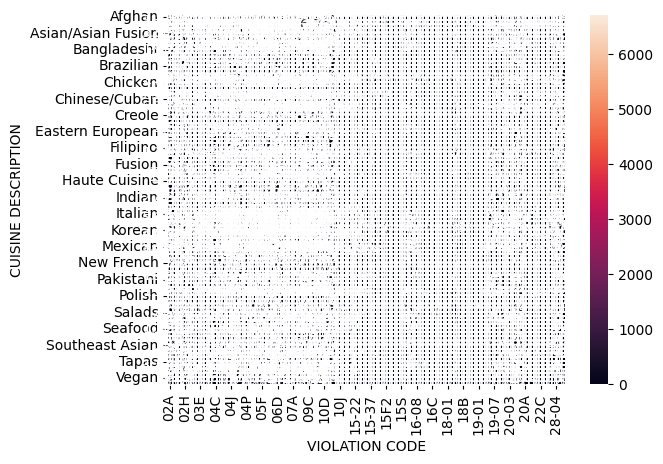

In [16]:
sns.heatmap(contingency_table, annot=True)

In [17]:
# this is too information dense. let's only look at 08A
contingency_table_only_08A = pd.crosstab(
    cuisine_x_vc['CUISINE DESCRIPTION'],
    cuisine_x_vc[cuisine_x_vc['VIOLATION CODE'] == '08A']['VIOLATION CODE']
);
contingency_table_only_08A

VIOLATION CODE,08A
CUISINE DESCRIPTION,
Afghan,19
African,131
American,3832
Armenian,9
Asian/Asian Fusion,459
...,...
Tex-Mex,251
Thai,436
Turkish,91


<Axes: xlabel='VIOLATION CODE', ylabel='CUISINE DESCRIPTION'>

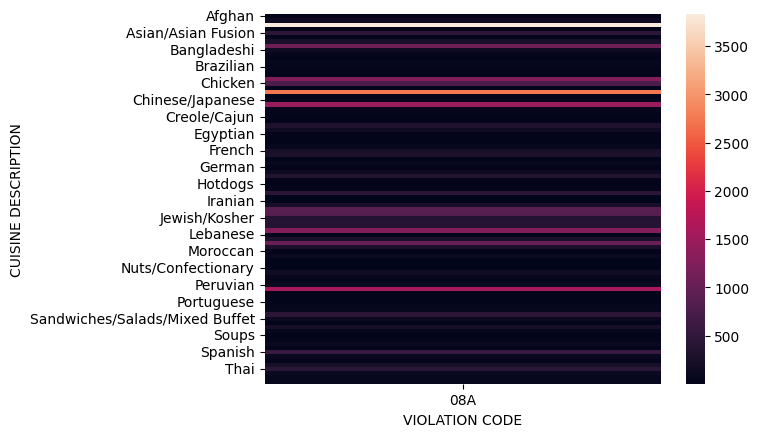

In [18]:
sns.heatmap(contingency_table_only_08A)

## because there are hotspots in this 1D heatmap, it makes sense now to investigate further